# Value at Risk con Monte Carlo y Volatilidad Dinámica (EWMA)

### Paso 0:

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt


# Descarga de datos
tickers = ["JPM","META","TSM","LLY"]
weights = np.array([0.25,0.25,0.25,0.25])

end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

data = yf.download(tickers,start=start,end=end)["Close"]
returns = data.pct_change().dropna()

n_sim=10000
n_days=252
n_assets=len(tickers)


C:\Users\j_ale\AppData\Local\Temp\ipykernel_19516\2378359340.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers,start=start,end=end)["Close"]
[*********************100%***********************]  4 of 4 completed


### Paso 1 : Calcular volatilidad EWMA histórica

In [7]:
lambda_ = 0.94

ewma_var = returns.var().copy()
ewma_vol_series = []

for t in range(len(returns)):
    r_t = returns.iloc[t]
    ewma_var = lambda_ * ewma_var + (1 - lambda_) * (r_t ** 2)
    ewma_vol_series.append(np.sqrt(ewma_var))

ewma_vol_df = pd.DataFrame(ewma_vol_series, 
                           index=returns.index, 
                           columns=returns.columns)

### Paso 2 : Correlaciones

In [8]:
corr_matrix = returns.corr()
L_corr = np.linalg.cholesky(corr_matrix)

### Paso 3 : Monte Carlo con volatilidad dinámica

In [9]:
sigma_t=ewma_vol_df.iloc[-1].values
portfolio_paths=np.zeros((n_sim,n_days))

for s in range(n_sim):

    sigma = sigma_t.copy()
    prices_sim = np.ones(n_assets)

    for t in range(n_days):

        z = np.random.normal(size=n_assets)
        correlated = L_corr @ z

        r = sigma * correlated

        prices_sim = prices_sim * (1 + r)

        port_ret = np.dot(weights, r)

        if t == 0:
            portfolio_paths[s, t] = 1 + port_ret
        else:
            portfolio_paths[s, t] = portfolio_paths[s, t-1] * (1 + port_ret)

        sigma = np.sqrt(lambda_ * sigma**2 + (1 - lambda_) * (r**2))

### Paso 4-  Calcular VaR

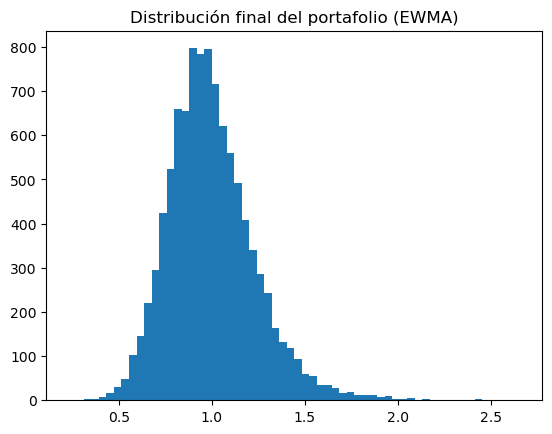

VaR 95%: 0.3371420674240614
Expected Shortfall 95%: 0.4105257980393763


In [10]:
final_values = portfolio_paths[:,-1]

plt.hist(final_values,bins=60)
plt.title("Distribución final del portafolio (EWMA)")
plt.show()

var_95 = np.percentile(final_values,5)
es_95 = final_values[final_values<=var_95].mean()

print("VaR 95%:",1-var_95)
print("Expected Shortfall 95%:",1-es_95)

### Tabla

In [21]:

tickers = ["JPM", "META", "TSM", "LLY"]
weights = np.array([0.25, 0.25, 0.25, 0.25])
n_sim = 10000
n_days = 15
confidence = 0.95
years_list = [1, 3, 5, 10]
end = dt.datetime.today()

results = []

np.random.seed(42)
for years in years_list:
    start = end - dt.timedelta(days=365 * years)
    data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
    returns = data.pct_change().dropna()
    n_assets = len(tickers)
    
    corr_matrix = returns.corr()
    L_corr = np.linalg.cholesky(corr_matrix)
    
    sigma_const = returns.std().values
    z = np.random.normal(size=(n_sim, n_days, n_assets))
    r_sim = np.einsum('sda,ba->sdb', z, L_corr) * sigma_const
    final_prices = np.prod(1 + r_sim, axis=1)
    portfolio_values_mgb = final_prices @ weights
    
    var_mgb = (1 - np.percentile(portfolio_values_mgb, 5)) * 100
    results.append(["MGB Constante", f"{years} años", var_mgb])
    
    for lam in [0.94, 0.8]:
        ewma_var = returns.var().copy()
        for t in range(len(returns)):
            r_t = returns.iloc[t]
            ewma_var = lam * ewma_var + (1 - lam) * (r_t ** 2)
        
        sigma_t_start = np.sqrt(ewma_var).values
        portfolio_values_ewma = np.zeros(n_sim)
        
        for s in range(n_sim):
            sigma = sigma_t_start.copy()
            prices_sim = np.ones(n_assets)
            for t in range(n_days):
                z_t = np.random.normal(size=n_assets)
                r_t = sigma * (L_corr @ z_t)
                prices_sim *= (1 + r_t)
                sigma = np.sqrt(lam * sigma**2 + (1 - lam) * (r_t**2))
            portfolio_values_ewma[s] = np.dot(weights, prices_sim)
            
        var_ewma = (1 - np.percentile(portfolio_values_ewma, 5)) * 100
        results.append([f"EWMA (λ={lam})", f"{years} años", var_ewma])

df_res = pd.DataFrame(results, columns=["Modelo", "Ventana Histórica", "VaR 95% (%)"])
tabla_final = df_res.pivot(index="Ventana Histórica", columns="Modelo", values="VaR 95% (%)")
tabla_final = tabla_final.reindex(["1 años", "3 años", "5 años", "10 años"])

print("\n--- TABLA COMPARATIVA DE RESULTADOS ---")
print(tabla_final)

C:\Users\j_ale\AppData\Local\Temp\ipykernel_19516\2854707685.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
C:\Users\j_ale\AppData\Local\Temp\ipykernel_19516\2854707685.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
C:\Users\j_ale\AppData\Local\Temp\ipykernel_19516\2854707685.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
C:\Users\j_ale\AppData\Local\Temp\ipykernel_19516\2854707685.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)["Close"]



--- TABLA COMPARATIVA DE RESULTADOS ---
Modelo             EWMA (λ=0.8)  EWMA (λ=0.94)  MGB Constante
Ventana Histórica                                            
1 años                 7.686225       9.769516      10.091202
3 años                 7.162403       9.281994       8.427366
5 años                 7.254647       9.318242       8.844559
10 años                7.387850       9.491130       8.698154
